# H6: Follicle Reconstruction — Addressing PALS Fragmentation and Spurious Annotations

**Problem 1:** Follicle tissue outlines are often discontinuous, broken by PALS (periarteriolar lymphoid sheath) which biologically courses through follicles. A single biological follicle may be segmented as multiple separate annotations.

**Problem 2:** The pixel classifier finds small CD20-positive areas that may not be bona fide follicles.

**Strategies:**
1. **White Pulp Composite** — Merge Follicle + PALS into functional "white pulp nodules"
2. **Spatial Clustering** — Reconstruct fragmented follicles via edge-to-edge proximity clustering
3. **Area Threshold** — Data-driven GMM threshold to remove spurious small annotations

> Applied in order: **filter (S3) → cluster (S2) → composite (S1)**, then compare genotype effects across all approaches.

In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, '.')
from data_utils import *

from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix
from scipy.stats import norm

setup_style()

df = load_data()
regions = get_regions(df)
vessels = get_vessels(df)

follicles = regions[regions['Classification'] == 'Follicle'].copy()
pals = regions[regions['Classification'] == 'PALS'].copy()

print(f"Follicles: {len(follicles):,} across {follicles['Image'].nunique()} images")
print(f"PALS:      {len(pals):,} across {pals['Image'].nunique()} images")
print(f"Vessels:   {len(vessels):,} (Follicle-parented: {(vessels['Region']=='Follicle').sum():,}, "
      f"PALS-parented: {(vessels['Region']=='PALS').sum():,})")
print(f"\nMedian follicle area: {follicles['Area µm^2'].median():.0f} µm² "
      f"({follicles['Area µm^2'].median()/1e6:.4f} mm²)")
print(f"75th percentile:      {follicles['Area µm^2'].quantile(0.75):.0f} µm²")
print(f"Follicles < 5,000 µm²: {(follicles['Area µm^2'] < 5000).sum()} "
      f"({(follicles['Area µm^2'] < 5000).mean()*100:.1f}%)")

Follicles: 2,457 across 12 images
PALS:      6,673 across 12 images
Vessels:   448,382 (Follicle-parented: 28,490, PALS-parented: 30,860)

Median follicle area: 4373 µm² (0.0044 mm²)
75th percentile:      67423 µm²
Follicles < 5,000 µm²: 1262 (51.4%)


---
## 1. Follicle Area Distribution

Inspect the size distribution to identify the bimodal split between spurious/fragment annotations and real follicles.

Saved: analysis/figures/H6_area_distribution.png


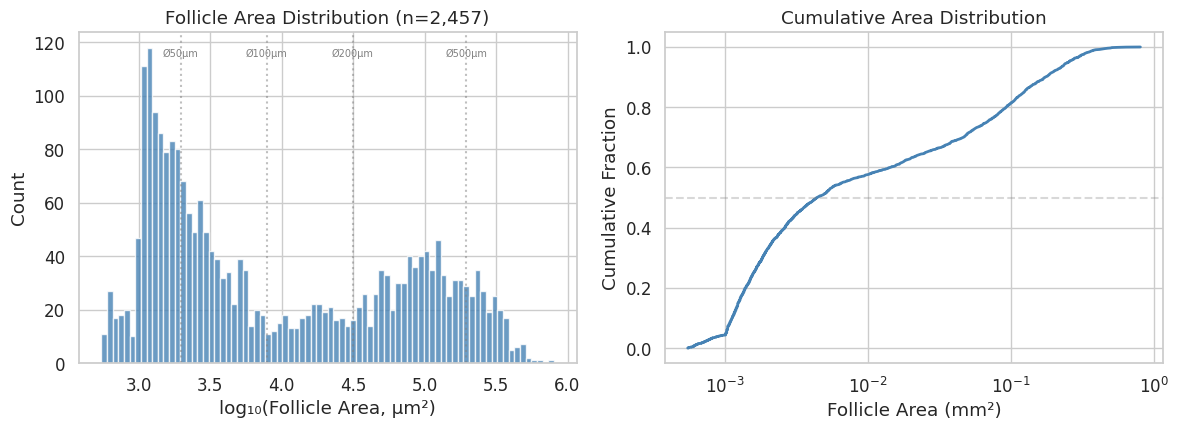

In [2]:
log_area = np.log10(follicles['Area µm^2'].values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram of log-area
axes[0].hist(log_area, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('log\u2081\u2080(Follicle Area, \u00b5m\u00b2)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Follicle Area Distribution (n={len(follicles):,})')

# Mark reference diameters
for diam, label in [(50, '50\u00b5m'), (100, '100\u00b5m'), (200, '200\u00b5m'), (500, '500\u00b5m')]:
    area = np.pi * (diam/2)**2
    axes[0].axvline(np.log10(area), color='gray', ls=':', alpha=0.5)
    axes[0].text(np.log10(area), axes[0].get_ylim()[1]*0.95, f'\u00d8{label}',
                 fontsize=7, ha='center', va='top', color='gray')

# Cumulative distribution
sorted_areas = np.sort(follicles['Area µm^2'].values)
axes[1].plot(sorted_areas / 1e6, np.arange(1, len(sorted_areas)+1) / len(sorted_areas),
             color='steelblue', linewidth=2)
axes[1].set_xlabel('Follicle Area (mm\u00b2)')
axes[1].set_ylabel('Cumulative Fraction')
axes[1].set_title('Cumulative Area Distribution')
axes[1].set_xscale('log')
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.3)

fig.tight_layout()
save_figure(fig, 'H6_area_distribution')
plt.show()

## 2. Strategy 3: Data-Driven Area Threshold (GMM)

Fit a 2-component Gaussian Mixture Model on log\u2081\u2080(area) to separate the "spurious/fragment" mode from the "real follicle" mode. The threshold is set at the intersection of the two components.

In [3]:
log_area_col = np.log10(follicles['Area µm^2'].values).reshape(-1, 1)

# Fit 2-component GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(log_area_col)

means = gmm.means_.flatten()
small_idx = int(np.argmin(means))
large_idx = int(np.argmax(means))

print(f"Component 'small': mean = 10^{means[small_idx]:.2f} = {10**means[small_idx]:.0f} \u00b5m\u00b2"
      f"  (\u00d8 {2*np.sqrt(10**means[small_idx]/np.pi):.0f} \u00b5m)")
print(f"Component 'large': mean = 10^{means[large_idx]:.2f} = {10**means[large_idx]:.0f} \u00b5m\u00b2"
      f"  (\u00d8 {2*np.sqrt(10**means[large_idx]/np.pi):.0f} \u00b5m)")
print(f"Weights:  small={gmm.weights_[small_idx]:.3f}, large={gmm.weights_[large_idx]:.3f}")

# Find intersection (threshold)
x_grid = np.linspace(log_area_col.min(), log_area_col.max(), 2000).reshape(-1, 1)
log_probs = gmm.predict_proba(x_grid)
# Find where large component probability exceeds small
large_dominant = log_probs[:, large_idx] > log_probs[:, small_idx]
crossings = np.where(np.diff(large_dominant.astype(int)))[0]

if len(crossings) > 0:
    threshold_log = x_grid[crossings[0], 0]
else:
    # Fallback: midpoint of means
    threshold_log = means.mean()

AREA_THRESHOLD = 10 ** threshold_log
print(f"\nGMM threshold: {AREA_THRESHOLD:.0f} \u00b5m\u00b2  (log\u2081\u2080 = {threshold_log:.2f})")
print(f"  = {AREA_THRESHOLD/1e6:.4f} mm\u00b2")
print(f"  \u2248 \u00d8 {2*np.sqrt(AREA_THRESHOLD/np.pi):.0f} \u00b5m if circular")

Component 'small': mean = 10^3.28 = 1923 µm²  (Ø 49 µm)
Component 'large': mean = 10^4.86 = 72259 µm²  (Ø 303 µm)
Weights:  small=0.565, large=0.435

GMM threshold: 8396 µm²  (log₁₀ = 3.92)
  = 0.0084 mm²
  ≈ Ø 103 µm if circular


Saved: analysis/figures/H6_gmm_threshold.png


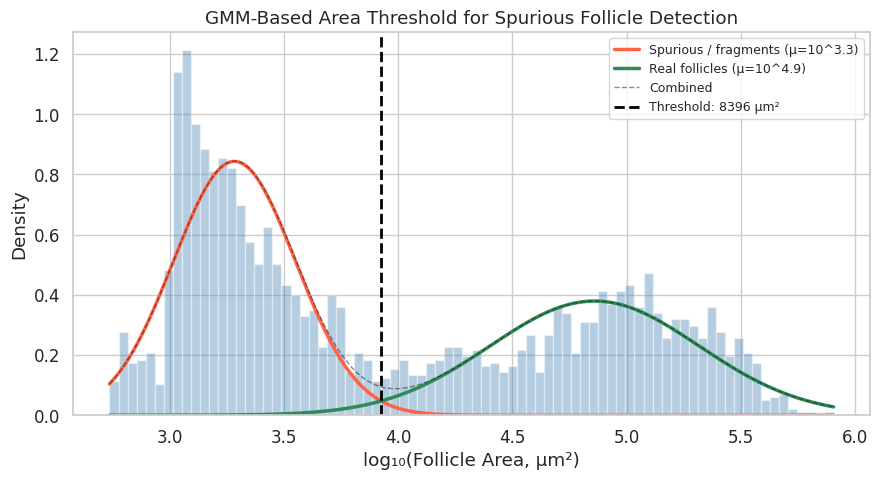

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(log_area_col, bins=80, density=True, color='steelblue', alpha=0.4, edgecolor='white')

# Plot GMM components
x_plot = np.linspace(log_area_col.min(), log_area_col.max(), 300)
for idx, (color, label) in zip([small_idx, large_idx],
    [('tomato', 'Spurious / fragments'), ('seagreen', 'Real follicles')]):
    mu = gmm.means_[idx, 0]
    sigma = np.sqrt(gmm.covariances_[idx, 0, 0])
    weight = gmm.weights_[idx]
    ax.plot(x_plot, weight * norm.pdf(x_plot, mu, sigma),
            color=color, linewidth=2.5, label=f'{label} (\u00b5=10^{mu:.1f})')

# Combined GMM density
total_density = sum(
    gmm.weights_[i] * norm.pdf(x_plot, gmm.means_[i, 0], np.sqrt(gmm.covariances_[i, 0, 0]))
    for i in range(2)
)
ax.plot(x_plot, total_density, 'k--', linewidth=1, alpha=0.5, label='Combined')

ax.axvline(threshold_log, color='black', linestyle='--', linewidth=2,
           label=f'Threshold: {AREA_THRESHOLD:.0f} \u00b5m\u00b2')

ax.set_xlabel('log\u2081\u2080(Follicle Area, \u00b5m\u00b2)')
ax.set_ylabel('Density')
ax.set_title('GMM-Based Area Threshold for Spurious Follicle Detection')
ax.legend(fontsize=9)

fig.tight_layout()
save_figure(fig, 'H6_gmm_threshold')
plt.show()

In [5]:
# Apply area threshold
follicles_filtered = follicles[follicles['Area µm^2'] >= AREA_THRESHOLD].copy()
removed = follicles[follicles['Area µm^2'] < AREA_THRESHOLD]

print(f"Original follicles:  {len(follicles):,}")
print(f"Removed (< threshold): {len(removed):,} ({len(removed)/len(follicles)*100:.1f}%)")
print(f"Retained:            {len(follicles_filtered):,} ({len(follicles_filtered)/len(follicles)*100:.1f}%)")
print(f"\nRemoved area = {removed['Area µm^2'].sum()/follicles['Area µm^2'].sum()*100:.2f}% of total follicle area")

# Per-image breakdown
rows = []
for image in sorted(follicles['Image'].unique()):
    orig = follicles[follicles['Image'] == image]
    filt = follicles_filtered[follicles_filtered['Image'] == image]
    rows.append({
        'Sample': orig['Sample'].iloc[0],
        'Genotype': orig['Genotype'].iloc[0],
        'Original': len(orig),
        'Retained': len(filt),
        'Removed': len(orig) - len(filt),
        'Pct_Removed': (len(orig) - len(filt)) / len(orig) * 100,
    })

filter_summary = pd.DataFrame(rows).sort_values('Sample').reset_index(drop=True)
save_table(filter_summary.round(1), 'H6_area_filter_summary')
display(filter_summary.round(1))

Original follicles:  2,457
Removed (< threshold): 1,389 (56.5%)
Retained:            1,068 (43.5%)

Removed area = 2.53% of total follicle area
Saved: analysis/tables/H6_area_filter_summary.csv


,Sample,Genotype,Original,Retained,Removed,Pct_Removed
0,1901HBMP004,T/T,54,11,43,79.6
1,HDL011,C/C,128,38,90,70.3
2,HDL018,C/T,98,24,74,75.5
3,HDL021,C/T,480,108,372,77.5
4,HDL043,C/T,176,91,85,48.3
5,HDL052,C/T,30,20,10,33.3
6,HDL053,C/C,406,194,212,52.2
7,HDL055,C/C,220,120,100,45.5
8,HDL063,T/T,293,240,53,18.1
9,HDL070,C/T,243,89,154,63.4


---
## 3. Strategy 2: Spatial Clustering of Follicle Fragments

After removing spurious small annotations, nearby follicle fragments (split by PALS) are merged using **edge-to-edge gap distance**:

$$\text{gap}_{ij} = \|c_i - c_j\| - r_i - r_j$$

where $r = \sqrt{A/\pi}$ is the estimated radius. Fragments with `gap < buffer` are connected, and connected components define merged follicles.

In [6]:
def cluster_annotations(ann_df, gap_buffer_um=150):
    """Cluster nearby annotations by edge-to-edge gap distance.

    For each image, builds a graph where annotations are connected if their
    estimated edges are within `gap_buffer_um` of each other, then finds
    connected components.

    Parameters
    ----------
    ann_df : DataFrame
        Annotations with 'Centroid X µm', 'Centroid Y µm', 'Area µm^2'.
    gap_buffer_um : float
        Maximum edge-to-edge gap (µm) to merge two annotations.

    Returns
    -------
    DataFrame with one row per cluster: Image, Sample, Genotype, Cluster_ID,
    N_fragments, Centroid X µm, Centroid Y µm, Area µm^2, Object_IDs,
    Classifications (set of original class labels in the cluster).
    """
    results = []

    for image, img_ann in ann_df.groupby('Image'):
        sample = img_ann['Sample'].iloc[0]
        geno = img_ann['Genotype'].iloc[0]
        coords = img_ann[['Centroid X µm', 'Centroid Y µm']].values
        areas = img_ann['Area µm^2'].values
        radii = np.sqrt(areas / np.pi)

        if len(img_ann) == 1:
            results.append({
                'Image': image, 'Sample': sample, 'Genotype': geno,
                'Cluster_ID': 0, 'N_fragments': 1,
                'Centroid X µm': coords[0, 0], 'Centroid Y µm': coords[0, 1],
                'Area µm^2': areas[0],
                'Object_IDs': [img_ann['Object ID'].iloc[0]],
                'Classifications': {img_ann['Classification'].iloc[0]},
            })
            continue

        # Pairwise centroid distances
        dists = squareform(pdist(coords))

        # Edge-to-edge gap
        r_sum = radii[:, None] + radii[None, :]
        gaps = dists - r_sum

        # Adjacency: connected if gap < buffer (exclude self-connections)
        adj = (gaps < gap_buffer_um) & (dists > 0)
        n_comp, labels = connected_components(csr_matrix(adj.astype(int)), directed=False)

        for cl in range(n_comp):
            mask = labels == cl
            cl_ann = img_ann.iloc[mask]
            cl_areas = areas[mask]
            cl_coords = coords[mask]

            # Area-weighted centroid
            weights = cl_areas / cl_areas.sum()
            w_centroid = (cl_coords * weights[:, None]).sum(axis=0)

            results.append({
                'Image': image, 'Sample': sample, 'Genotype': geno,
                'Cluster_ID': cl, 'N_fragments': int(mask.sum()),
                'Centroid X µm': w_centroid[0], 'Centroid Y µm': w_centroid[1],
                'Area µm^2': cl_areas.sum(),
                'Object_IDs': cl_ann['Object ID'].tolist(),
                'Classifications': set(cl_ann['Classification']),
            })

    return pd.DataFrame(results)

Saved: analysis/figures/H6_clustering_sensitivity.png


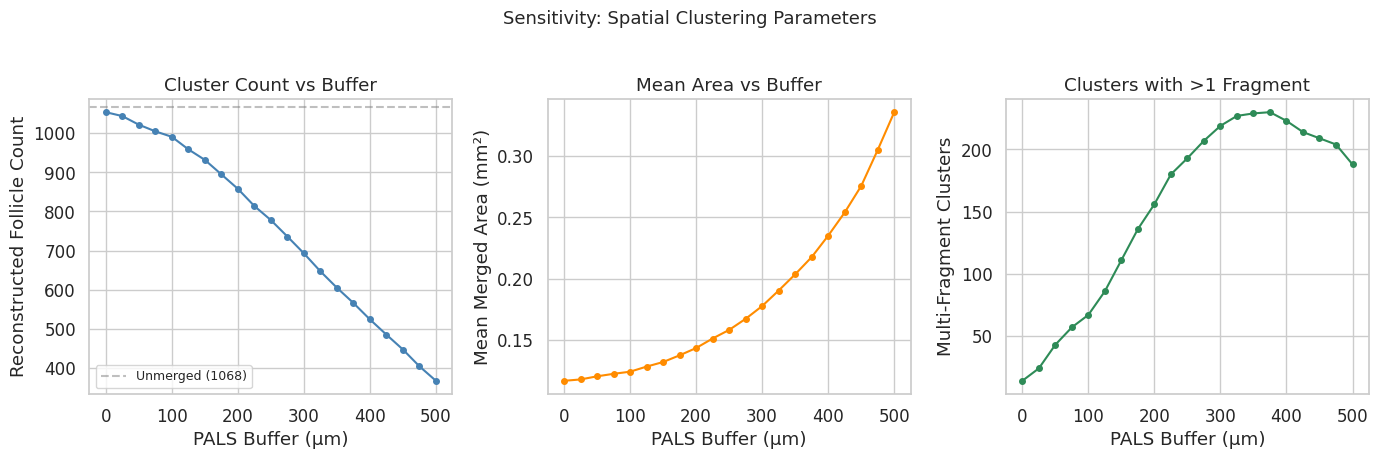

,Buffer_um,N_clusters,Multi_fragment,Mean_area_mm2,Max_fragments,Pct_merged
0,0,1054,14,0.1169,2,1.3283
2,50,1022,43,0.1206,4,4.2074
4,100,991,67,0.1243,6,6.7608
6,150,932,111,0.1322,10,11.9099
8,200,858,156,0.1436,10,18.1818
12,300,693,219,0.1778,11,31.6017
20,500,367,188,0.3357,35,51.2262


In [7]:
# Sensitivity analysis: how does the buffer affect clustering?
buffers = np.arange(0, 501, 25)
sensitivity = []

for buf in buffers:
    merged = cluster_annotations(follicles_filtered, gap_buffer_um=buf)
    sensitivity.append({
        'Buffer_um': buf,
        'N_clusters': len(merged),
        'Multi_fragment': int((merged['N_fragments'] > 1).sum()),
        'Mean_area_mm2': merged['Area µm^2'].mean() / 1e6,
        'Max_fragments': int(merged['N_fragments'].max()),
        'Pct_merged': (merged['N_fragments'] > 1).sum() / len(merged) * 100,
    })

sens_df = pd.DataFrame(sensitivity)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].plot(sens_df['Buffer_um'], sens_df['N_clusters'], 'o-', color='steelblue', markersize=4)
axes[0].axhline(len(follicles_filtered), color='gray', ls='--', alpha=0.5, label=f'Unmerged ({len(follicles_filtered)})')
axes[0].set_xlabel('PALS Buffer (\u00b5m)')
axes[0].set_ylabel('Reconstructed Follicle Count')
axes[0].set_title('Cluster Count vs Buffer')
axes[0].legend(fontsize=9)

axes[1].plot(sens_df['Buffer_um'], sens_df['Mean_area_mm2'], 'o-', color='darkorange', markersize=4)
axes[1].set_xlabel('PALS Buffer (\u00b5m)')
axes[1].set_ylabel('Mean Merged Area (mm\u00b2)')
axes[1].set_title('Mean Area vs Buffer')

axes[2].plot(sens_df['Buffer_um'], sens_df['Multi_fragment'], 'o-', color='seagreen', markersize=4)
axes[2].set_xlabel('PALS Buffer (\u00b5m)')
axes[2].set_ylabel('Multi-Fragment Clusters')
axes[2].set_title('Clusters with >1 Fragment')

fig.suptitle('Sensitivity: Spatial Clustering Parameters', fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, 'H6_clustering_sensitivity')
plt.show()

display(sens_df[sens_df['Buffer_um'].isin([0, 50, 100, 150, 200, 300, 500])].round(4))

In [8]:
# -------------------------------------------------------------------
# Choose a buffer — inspect the sensitivity plot above and adjust here
# -------------------------------------------------------------------
PALS_BUFFER = 150  # µm — adjust based on sensitivity analysis

merged_follicles = cluster_annotations(follicles_filtered, gap_buffer_um=PALS_BUFFER)
merged_follicles['Area_mm2'] = merged_follicles['Area µm^2'] / 1e6

n_multi = (merged_follicles['N_fragments'] > 1).sum()
print(f"Buffer = {PALS_BUFFER} \u00b5m")
print(f"Reconstructed follicles: {len(merged_follicles):,} (from {len(follicles_filtered):,} filtered annotations)")
print(f"Multi-fragment clusters: {n_multi} ({n_multi/len(merged_follicles)*100:.1f}%)")
print(f"\nFragment distribution:")
print(merged_follicles['N_fragments'].value_counts().sort_index().to_string())

# Per-image summary
merge_img = merged_follicles.groupby(['Image', 'Sample', 'Genotype'], observed=True).agg(
    N_merged=('Area µm^2', 'count'),
    Total_Area_mm2=('Area_mm2', 'sum'),
    Mean_Area_mm2=('Area_mm2', 'mean'),
    Max_Fragments=('N_fragments', 'max'),
).reset_index()

save_table(merge_img.round(4), 'H6_merged_follicle_summary')
display(merge_img[['Sample', 'Genotype', 'N_merged', 'Total_Area_mm2', 'Mean_Area_mm2', 'Max_Fragments']].round(4))

Buffer = 150 µm
Reconstructed follicles: 932 (from 1,068 filtered annotations)
Multi-fragment clusters: 111 (11.9%)

Fragment distribution:
N_fragments
1     821
2      98
3       8
4       3
5       1
10      1
Saved: analysis/tables/H6_merged_follicle_summary.csv


,Sample,Genotype,N_merged,Total_Area_mm2,Mean_Area_mm2,Max_Fragments
0,1901HBMP004,T/T,10,2.1934,0.2193,2
1,HDL011,C/C,37,4.0933,0.1106,2
2,HDL018,C/T,19,0.8322,0.0438,3
3,HDL021,C/T,87,15.8871,0.1826,4
4,HDL043,C/T,84,18.1201,0.2157,2
5,HDL052,C/T,17,1.4635,0.0861,2
6,HDL053,C/C,140,32.4341,0.2317,10
7,HDL055,C/C,106,8.0248,0.0757,2
8,HDL063,T/T,228,15.0961,0.0662,2
9,HDL070,C/T,80,8.3487,0.1044,2


---
## 4. Strategy 1: White Pulp Composite Units

Combine **Follicle + PALS** annotations into "white pulp nodules" using the same spatial clustering. Since PALS biologically courses through follicles, this captures the complete functional unit.

Also computed: a simple **image-level** Follicle+PALS aggregate (no spatial clustering, just summing areas).

In [9]:
# --- Image-level WhitePulp aggregate (simple) ---
wp_regions = regions[regions['Classification'].isin(['Follicle', 'PALS'])].copy()

wp_image = wp_regions.groupby(['Image', 'Sample', 'Genotype'], observed=True).agg(
    WP_Area_um2=('Area µm^2', 'sum'),
    N_annotations=('Area µm^2', 'count'),
).reset_index()
wp_image['WP_Area_mm2'] = wp_image['WP_Area_um2'] / 1e6

# Vessel counts: Follicle + PALS parented
wp_vessels = vessels[vessels['Region'].isin(['Follicle', 'PALS'])]
wp_vcounts = wp_vessels.groupby(['Image'], observed=True).size().reset_index(name='WP_Vessel_Count')
wp_image = wp_image.merge(wp_vcounts, on='Image', how='left')
wp_image['WP_Vessel_Count'] = wp_image['WP_Vessel_Count'].fillna(0).astype(int)
wp_image['WP_Density'] = wp_image['WP_Vessel_Count'] / wp_image['WP_Area_mm2']

print("=== Image-Level White Pulp Aggregates ===")
display(wp_image[['Sample', 'Genotype', 'N_annotations', 'WP_Area_mm2',
                  'WP_Vessel_Count', 'WP_Density']].round(2))

# --- Spatially-clustered WhitePulp nodules ---
# Filter PALS by same area threshold
pals_filtered = pals[pals['Area µm^2'] >= AREA_THRESHOLD].copy()
wp_filtered = pd.concat([follicles_filtered, pals_filtered], ignore_index=True)

wp_nodules = cluster_annotations(wp_filtered, gap_buffer_um=PALS_BUFFER)
wp_nodules['Area_mm2'] = wp_nodules['Area µm^2'] / 1e6
wp_nodules['Has_Follicle'] = wp_nodules['Classifications'].apply(lambda s: 'Follicle' in s)
wp_nodules['Has_PALS'] = wp_nodules['Classifications'].apply(lambda s: 'PALS' in s)
wp_nodules['Has_Both'] = wp_nodules['Has_Follicle'] & wp_nodules['Has_PALS']

print(f"\n=== Spatially-Clustered White Pulp Nodules (buffer={PALS_BUFFER} \u00b5m) ===")
print(f"Total nodules: {len(wp_nodules):,}")
print(f"  Follicle-only: {(wp_nodules['Has_Follicle'] & ~wp_nodules['Has_PALS']).sum()}")
print(f"  PALS-only:     {(wp_nodules['Has_PALS'] & ~wp_nodules['Has_Follicle']).sum()}")
print(f"  Mixed (F+P):   {wp_nodules['Has_Both'].sum()}")
print(f"  Mean fragments/nodule: {wp_nodules['N_fragments'].mean():.1f}")

=== Image-Level White Pulp Aggregates ===


,Sample,Genotype,N_annotations,WP_Area_mm2,WP_Vessel_Count,WP_Density
0,1901HBMP004,T/T,82,2.47,809,327.18
1,HDL011,C/C,1296,15.69,4441,283.01
2,HDL018,C/T,110,1.15,205,178.81
3,HDL021,C/T,626,18.58,6377,343.22
4,HDL043,C/T,648,27.77,2425,87.33
5,HDL052,C/T,92,2.36,273,115.78
6,HDL053,C/C,2654,61.45,25208,410.21
7,HDL055,C/C,554,12.25,2292,187.06
8,HDL063,T/T,1089,26.46,4992,188.64
9,HDL070,C/T,841,18.70,6923,370.19



=== Spatially-Clustered White Pulp Nodules (buffer=150 µm) ===
Total nodules: 1,084
  Follicle-only: 268
  PALS-only:     302
  Mixed (F+P):   514
  Mean fragments/nodule: 2.2


---
## 5. Genotype Comparisons Across Approaches

Compare the key follicular metrics (count, area, vessel density) under each approach to see how robust genotype effects are.

In [10]:
# Helper: build per-image follicle summary for a given set of annotations
def image_fol_summary(fol_df, label, vessel_df=None):
    """Compute per-image follicle count, area, and vessel density."""
    img = fol_df.groupby(['Image', 'Sample', 'Genotype'], observed=True).agg(
        Count=('Area µm^2', 'count'),
        Total_Area_mm2=('Area µm^2', lambda x: x.sum() / 1e6),
        Mean_Area_mm2=('Area µm^2', lambda x: x.mean() / 1e6),
    ).reset_index()

    if vessel_df is not None:
        vc = vessel_df.groupby('Image', observed=True).size().reset_index(name='Vessel_Count')
        img = img.merge(vc, on='Image', how='left')
        img['Vessel_Count'] = img['Vessel_Count'].fillna(0).astype(int)
        img['Density_per_mm2'] = img['Vessel_Count'] / img['Total_Area_mm2']
    else:
        img['Vessel_Count'] = np.nan
        img['Density_per_mm2'] = np.nan

    img['Approach'] = label
    return img


# 1. Original (unfiltered)
fol_vessels = vessels[vessels['Region'] == 'Follicle']
orig_summary = image_fol_summary(follicles, 'Original', fol_vessels)

# 2. After area filter (Strategy 3)
# Only count vessels whose parent follicle was retained
retained_ids = set(follicles_filtered['Object ID'])
# Vessels parented by Follicle — we can't directly filter by parent Object ID
# since vessels just say 'Annotation (Follicle)'. Use cKDTree to assign.
filt_summary = image_fol_summary(follicles_filtered, 'Area-Filtered', fol_vessels)

# 3. After spatial clustering (Strategy 2) — use merged areas
clust_summary = image_fol_summary(merged_follicles, 'Clustered (S2)', fol_vessels)

# 4. White Pulp composite (Strategy 1) — image-level
wp_summary = wp_image[['Image', 'Sample', 'Genotype', 'WP_Area_mm2',
                        'WP_Vessel_Count', 'WP_Density']].copy()
wp_summary.columns = ['Image', 'Sample', 'Genotype', 'Total_Area_mm2',
                       'Vessel_Count', 'Density_per_mm2']
wp_summary['Approach'] = 'WhitePulp (S1)'
# Count = WP nodules per image
wp_nod_counts = wp_nodules.groupby(['Image'], observed=True).size().reset_index(name='Count')
wp_summary = wp_summary.merge(wp_nod_counts, on='Image', how='left')
wp_summary['Mean_Area_mm2'] = wp_summary['Total_Area_mm2'] / wp_summary['Count']

# Combine
comparison = pd.concat([orig_summary, filt_summary, clust_summary, wp_summary], ignore_index=True)
comparison['Genotype'] = pd.Categorical(comparison['Genotype'], categories=GENO_ORDER, ordered=True)

# Pivot table: mean per genotype per approach
pivot = comparison.groupby(['Approach', 'Genotype'], observed=True).agg(
    Mean_Count=('Count', 'mean'),
    Mean_Total_Area=('Total_Area_mm2', 'mean'),
    Mean_Unit_Area=('Mean_Area_mm2', 'mean'),
    Mean_Density=('Density_per_mm2', 'mean'),
).round(2)

save_table(pivot.reset_index(), 'H6_approach_comparison')
display(pivot)

Saved: analysis/tables/H6_approach_comparison.csv


Mean_Count  Mean_Total_Area  Mean_Unit_Area  \
Approach       Genotype                                                
Area-Filtered  C/C           117.33            14.85            0.11   
               C/T            73.00             9.93            0.11   
               T/T            92.67             6.35            0.11   
Clustered (S2) C/C            94.33            14.85            0.14   
               C/T            64.67             9.93            0.13   
               T/T            87.00             6.35            0.12   
Original       C/C           251.33            15.18            0.05   
               C/T           195.67            10.22            0.06   
               T/T           176.33             6.52            0.04   
WhitePulp (S1) C/C           127.67            29.80            0.22   
               C/T            72.17            15.99            0.18   
               T/T            89.33            10.39            0.15   

                         Mean_Density  
Approach       Genotype                
Area-Filtered  C/C             243.82  
               C/T             203.72  
               T/T             334.19  
Clustered (S2) C/C             243.82  
               C/T             203.72  
               T/T             334.19  
Original       C/C             236.14  
               C/T             191.23  
               T/T             308.25  
WhitePulp (S1) C/C             293.43  
               C/T             209.44  
               T/T             319.67

/tmp/ipykernel_331924/543846480.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_331924/543846480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_331924/543846480.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_331924/543846480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

/tmp/ipykernel_331924/543846480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_331924/543846480.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_331924/543846480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_331924/543846480.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

Saved: analysis/figures/H6_genotype_comparison_grid.png


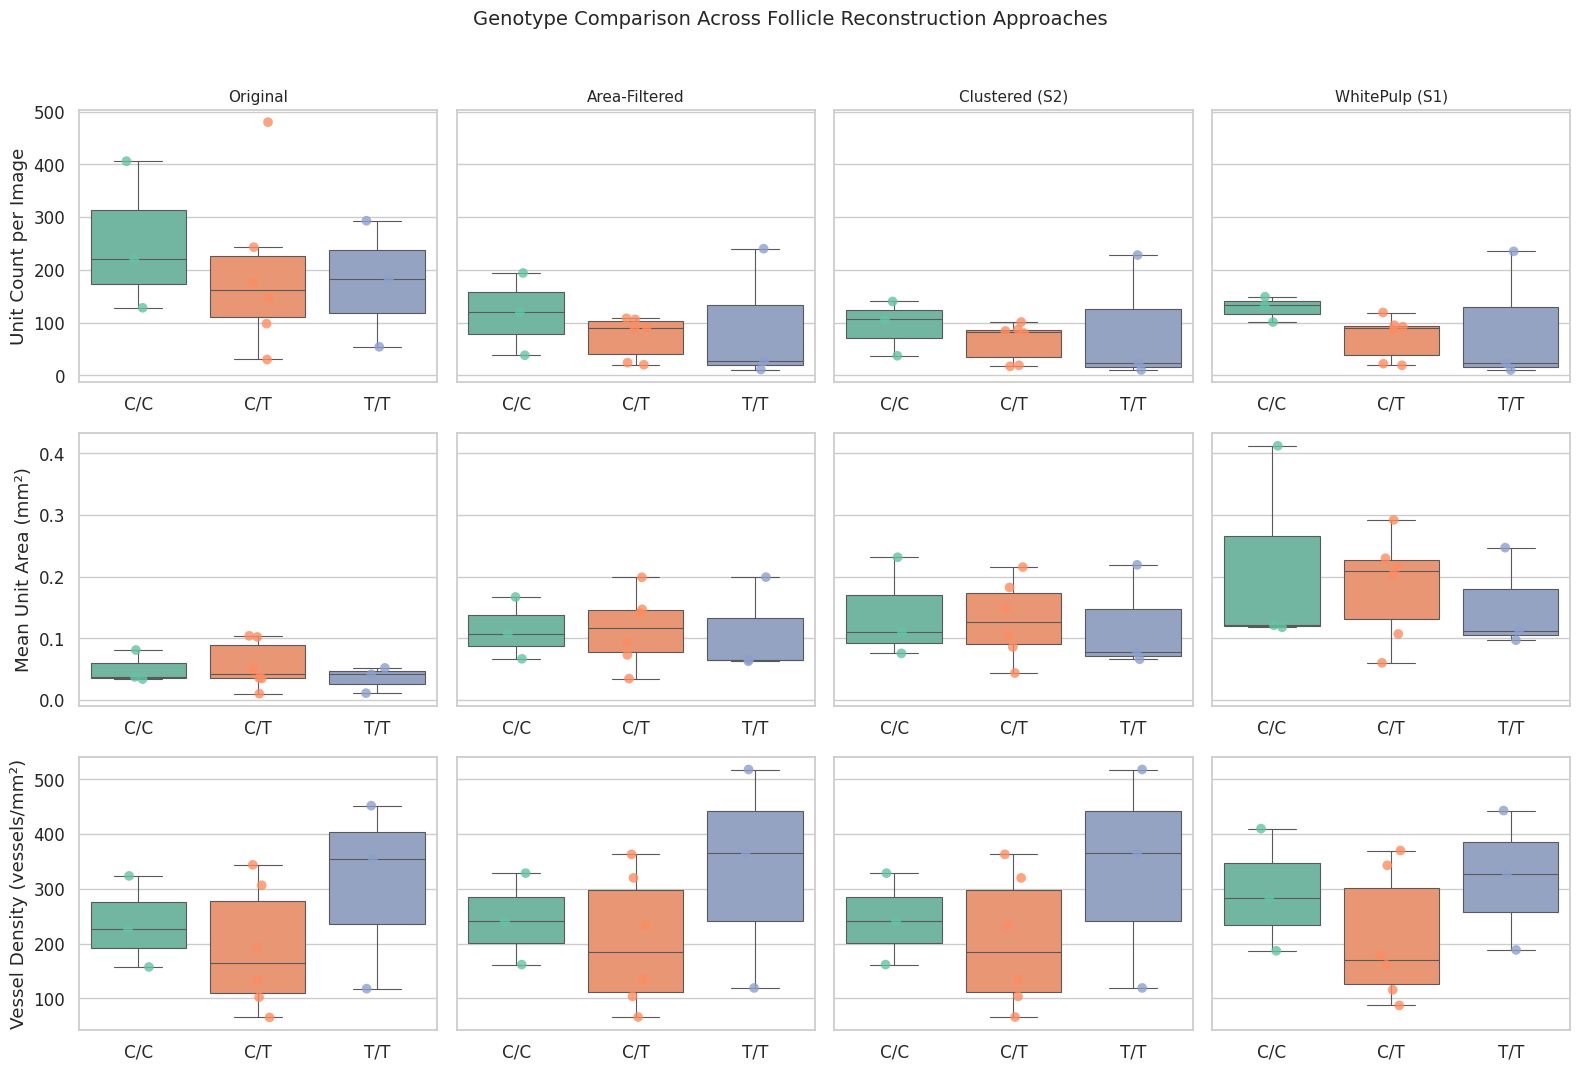

In [11]:
approach_order = ['Original', 'Area-Filtered', 'Clustered (S2)', 'WhitePulp (S1)']
metrics = [
    ('Count', 'Unit Count per Image'),
    ('Mean_Area_mm2', 'Mean Unit Area (mm\u00b2)'),
    ('Density_per_mm2', 'Vessel Density (vessels/mm\u00b2)'),
]

fig, axes = plt.subplots(len(metrics), len(approach_order), figsize=(16, 3.5*len(metrics)),
                         sharey='row')

for row, (col, ylabel) in enumerate(metrics):
    for j, approach in enumerate(approach_order):
        ax = axes[row, j]
        sub = comparison[comparison['Approach'] == approach]
        if sub[col].isna().all():
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        else:
            sns.boxplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
                        palette=GENO_PALETTE, ax=ax, linewidth=0.8, fliersize=0)
            sns.stripplot(data=sub, x='Genotype', y=col, order=GENO_ORDER,
                          palette=GENO_PALETTE, ax=ax, size=7, alpha=0.8)
        if j == 0:
            ax.set_ylabel(ylabel)
        else:
            ax.set_ylabel('')
        if row == 0:
            ax.set_title(approach, fontsize=11)
        ax.set_xlabel('')

fig.suptitle('Genotype Comparison Across Follicle Reconstruction Approaches',
             fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'H6_genotype_comparison_grid')
plt.show()

In [12]:
# Statistical tests across approaches
all_stats = []

for approach in approach_order:
    sub = comparison[comparison['Approach'] == approach]
    for col, label in [('Count', 'Count'), ('Mean_Area_mm2', 'Mean area'),
                        ('Density_per_mm2', 'Vessel density')]:
        if sub[col].isna().all():
            continue
        st = full_stats_table(sub, col, label=f'{approach}: {label}')
        all_stats.append(st)

stats_all = pd.concat(all_stats, ignore_index=True)
save_table(stats_all, 'H6_statistical_tests')

# Show just Kruskal-Wallis and Spearman rows for compactness
display(stats_all[stats_all['Test'].isin(['Kruskal-Wallis', 'Spearman dosage'])])

Saved: analysis/tables/H6_statistical_tests.csv


,Test,Metric,Statistic,p,Effect_Size
0,Kruskal-Wallis,Original: Count,0.435897,0.804167,
4,Spearman dosage,Original: Count,-0.136558,0.672157,rho=-0.137
5,Kruskal-Wallis,Original: Mean area,0.115385,0.943940,
9,Spearman dosage,Original: Mean area,-0.034139,0.916115,rho=-0.034
10,Kruskal-Wallis,Original: Vessel density,1.961538,0.375023,
14,Spearman dosage,Original: Vessel density,0.170697,0.595823,rho=0.171
15,Kruskal-Wallis,Area-Filtered: Count,1.448718,0.484635,
19,Spearman dosage,Area-Filtered: Count,-0.307255,0.331313,rho=-0.307
20,Kruskal-Wallis,Area-Filtered: Mean area,0.230769,0.891023,
24,Spearman dosage,Area-Filtered: Mean area,-0.136558,0.672157,rho=-0.137


### Vessel Re-Assignment to Merged Follicles

Re-assign follicle-parented vessels to the nearest **merged** follicle centroid (Strategy 2) or white pulp nodule centroid (Strategy 1), then recompute per-unit vessel counts.

In [13]:
def assign_vessels_to_clusters(cluster_df, vessel_df, vessel_regions=('Follicle',)):
    """Assign vessels to nearest cluster centroid using cKDTree, per image.

    Parameters
    ----------
    cluster_df : DataFrame from cluster_annotations()
    vessel_df : DataFrame from get_vessels()
    vessel_regions : tuple of regions to include (e.g., ('Follicle',) or ('Follicle','PALS'))

    Returns
    -------
    DataFrame: per-cluster vessel counts and densities.
    """
    from scipy.spatial import cKDTree
    all_results = []

    for image, cl_img in cluster_df.groupby('Image'):
        img_vessels = vessel_df[(vessel_df['Image'] == image) &
                               (vessel_df['Region'].isin(vessel_regions))]

        cl_coords = cl_img[['Centroid X µm', 'Centroid Y µm']].values
        cl_areas = cl_img['Area µm^2'].values

        if img_vessels.empty or len(cl_img) == 0:
            for i, row in cl_img.iterrows():
                all_results.append({
                    'Image': image, 'Sample': row['Sample'], 'Genotype': row['Genotype'],
                    'Cluster_ID': row['Cluster_ID'], 'Area µm^2': row['Area µm^2'],
                    'Vessel_Count': 0, 'Vessel_Density': 0,
                })
            continue

        tree = cKDTree(cl_coords)
        ves_coords = img_vessels[['Centroid X µm', 'Centroid Y µm']].values
        _, indices = tree.query(ves_coords)

        # Count per cluster
        counts = pd.Series(indices).value_counts()
        for i, row in cl_img.reset_index(drop=True).iterrows():
            vc = counts.get(i, 0)
            area_mm2 = row['Area µm^2'] / 1e6
            all_results.append({
                'Image': image, 'Sample': row['Sample'], 'Genotype': row['Genotype'],
                'Cluster_ID': row['Cluster_ID'], 'Area µm^2': row['Area µm^2'],
                'Vessel_Count': int(vc),
                'Vessel_Density': vc / area_mm2 if area_mm2 > 0 else 0,
            })

    return pd.DataFrame(all_results)


# Strategy 2: vessels assigned to merged follicle clusters
s2_per_unit = assign_vessels_to_clusters(merged_follicles, vessels, vessel_regions=('Follicle',))

# Strategy 1: vessels assigned to WP nodules (Follicle + PALS vessels)
s1_per_unit = assign_vessels_to_clusters(wp_nodules, vessels, vessel_regions=('Follicle', 'PALS'))

print(f"S2 — Merged follicles: {len(s2_per_unit)} units, "
      f"{s2_per_unit['Vessel_Count'].sum()} vessels assigned")
print(f"S1 — WP nodules:       {len(s1_per_unit)} units, "
      f"{s1_per_unit['Vessel_Count'].sum()} vessels assigned")

S2 — Merged follicles: 932 units, 28490 vessels assigned
S1 — WP nodules:       1084 units, 59350 vessels assigned


/tmp/ipykernel_331924/630416389.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=img_med, x='Genotype', y='Vessel_Density', order=GENO_ORDER,
/tmp/ipykernel_331924/630416389.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=img_med, x='Genotype', y='Vessel_Density', order=GENO_ORDER,
/tmp/ipykernel_331924/630416389.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=img_med, x='Genotype', y='Vessel_Density', order=GENO_ORDER,
/tmp/ipykernel_331924/630416389.py:37: FutureWarning: 

Passing `palette` without assigning 

Saved: analysis/figures/H6_per_unit_vessel_density.png


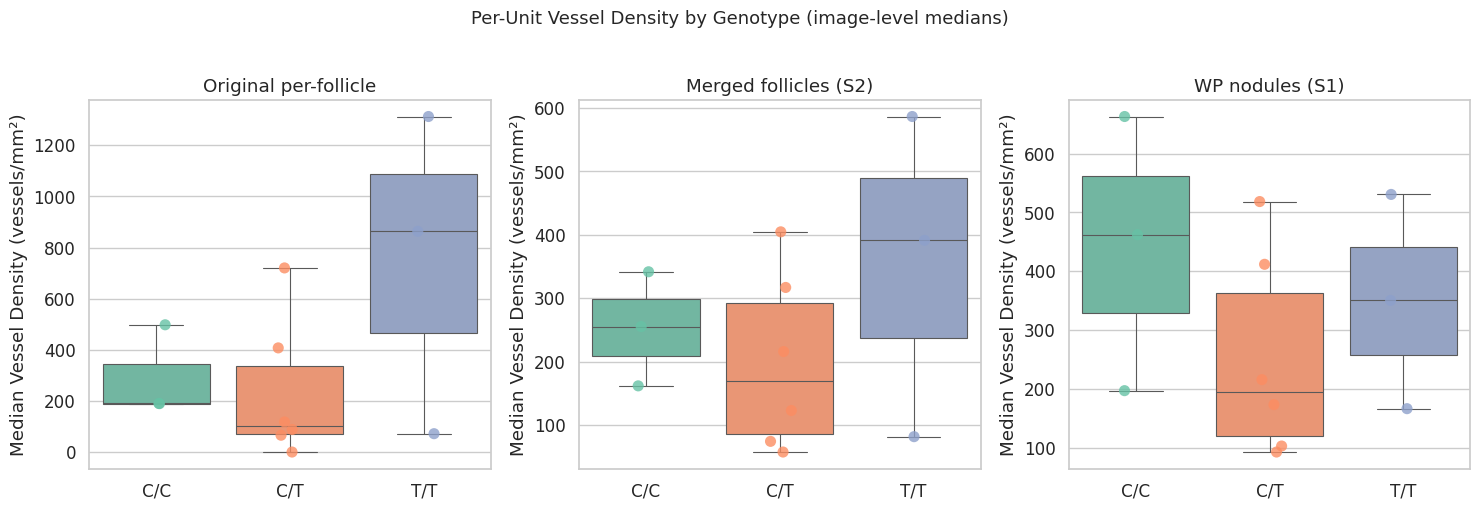

In [14]:
# Per-unit vessel density comparison — rebuild original per-follicle from scratch
_all_assigned = []
for image in df['Image'].unique():
    _assigned = assign_vessels_to_follicles(df, image)
    if not _assigned.empty:
        _all_assigned.append(_assigned)

_fol_ves = pd.concat(_all_assigned, ignore_index=True)
_per_fol = _fol_ves.groupby(['Image', 'Sample', 'Genotype', 'Follicle_ID', 'Follicle_Area'],
                             observed=True).size().reset_index(name='Vessel_Count')
_per_fol['Vessel_Density'] = _per_fol['Vessel_Count'] / (_per_fol['Follicle_Area'] / 1e6)

# Include zero-vessel follicles
_all_fol = regions[regions['Classification'] == 'Follicle'][
    ['Image', 'Sample', 'Genotype', 'Object ID', 'Area µm^2']].copy()
_all_fol.columns = ['Image', 'Sample', 'Genotype', 'Follicle_ID', 'Follicle_Area']
orig_per_fol = _all_fol.merge(
    _per_fol[['Follicle_ID', 'Vessel_Count', 'Vessel_Density']],
    on='Follicle_ID', how='left')
orig_per_fol['Vessel_Count'] = orig_per_fol['Vessel_Count'].fillna(0).astype(int)
orig_per_fol['Vessel_Density'] = orig_per_fol['Vessel_Count'] / (orig_per_fol['Follicle_Area'] / 1e6)

datasets = [
    (orig_per_fol, 'Original per-follicle'),
    (s2_per_unit, 'Merged follicles (S2)'),
    (s1_per_unit, 'WP nodules (S1)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (data, title) in zip(axes, datasets):
    # Per-image median
    img_med = data.groupby(['Image', 'Sample', 'Genotype'], observed=True)['Vessel_Density'].median().reset_index()
    img_med['Genotype'] = pd.Categorical(img_med['Genotype'], categories=GENO_ORDER, ordered=True)
    sns.boxplot(data=img_med, x='Genotype', y='Vessel_Density', order=GENO_ORDER,
                palette=GENO_PALETTE, ax=ax, linewidth=0.8, fliersize=0)
    sns.stripplot(data=img_med, x='Genotype', y='Vessel_Density', order=GENO_ORDER,
                  palette=GENO_PALETTE, ax=ax, size=8, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Median Vessel Density (vessels/mm\u00b2)')
    ax.set_xlabel('')

fig.suptitle('Per-Unit Vessel Density by Genotype (image-level medians)', fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, 'H6_per_unit_vessel_density')
plt.show()

---
## 6. Before/After Mask Visualization

Render binary masks from QuPath GeoJSON annotation exports to visualize the Follicle + PALS → white pulp nodule transformation.

- **Before:** Original pixel-classifier output — Follicle (blue) and PALS (orange) as separate annotations
- **After:** Merged white pulp nodules (green) after area filtering (S3) and spatial merging (S1+S2)

In [15]:
from pathlib import Path
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union
from shapely.affinity import translate as stranslate, scale as sscale
from PIL import Image as PILImage, ImageDraw

GEOJSON_DIR = PROJECT / 'analysis' / 'geojson'

# Per-image pixel sizes (µm/pixel)
_PIXEL_SIZES = {
    '1901HBMP004': 0.374,
    'HDL073':      0.374,
}
_DEFAULT_PIXEL_SIZE = 0.5077663810243286

def get_pixel_size(sample_id):
    """Return pixel size in µm/pixel for a given sample."""
    return _PIXEL_SIZES.get(sample_id, _DEFAULT_PIXEL_SIZE)


def load_annotations_geojson(geojson_path):
    """Load QuPath GeoJSON and return {classification_name: [shapely Polygon]}."""
    with open(geojson_path) as f:
        data = json.load(f)

    annotations = {}
    for feat in data.get('features', []):
        cls = feat.get('properties', {}).get('classification', {}).get('name', 'Unknown')
        geom = shape(feat['geometry'])
        annotations.setdefault(cls, []).append(geom)

    return annotations


def polygons_to_mask(polygons, image_shape):
    """Rasterize shapely polygons to a boolean mask.

    Parameters
    ----------
    polygons : list of shapely Polygon/MultiPolygon (pixel coordinates)
    image_shape : (height, width)
    """
    h, w = image_shape
    img = PILImage.new('L', (w, h), 0)
    draw = ImageDraw.Draw(img)

    for poly in polygons:
        if poly.is_empty:
            continue
        parts = list(poly.geoms) if poly.geom_type == 'MultiPolygon' else [poly]
        for p in parts:
            coords = list(p.exterior.coords)
            if len(coords) < 3:
                continue
            draw.polygon(coords, fill=1)
            for hole in p.interiors:
                draw.polygon(list(hole.coords), fill=0)

    return np.array(img, dtype=bool)


def merge_nearby_polygons(polygons, buffer_px):
    """Merge polygons that overlap after buffering outward, then erode back."""
    buffered = [p.buffer(buffer_px) for p in polygons if not p.is_empty]
    if not buffered:
        return []
    merged = unary_union(buffered).buffer(-buffer_px)
    if merged.is_empty:
        return []
    if merged.geom_type == 'Polygon':
        return [merged]
    return list(merged.geoms)


# List available GeoJSON files
geojson_files = sorted(GEOJSON_DIR.glob('*.geojson'))
print(f"Found {len(geojson_files)} GeoJSON files in {GEOJSON_DIR.relative_to(PROJECT)}/")
for f in geojson_files:
    print(f"  {f.name}")

Found 13 GeoJSON files in analysis/geojson/
  1901HBMP004_PC29.geojson
  HDL011_PC33.geojson
  HDL018_PC25.geojson
  HDL021_PC25.geojson
  HDL043_PC33.geojson
  HDL052SPLN_2025Aug6_Scan1.er.qptiff - resolution #1.geojson
  HDL053_PC33.geojson
  HDL055_PC33.geojson
  HDL063_PC33.geojson
  HDL070_SPLN_2025Aug8_Scan1.er.qptiff - resolution #1.geojson
  HDL073_PC29.geojson
  HDL086_PC33.geojson
  HDL172_PC33.geojson


Rendering masks for 12 images...



HDL011 (C/C, 0.508 µm/px): 128 Follicle, 1168 PALS

 → 84 WP nodules


HDL053 (C/C, 0.508 µm/px): 406 Follicle, 2248 PALS

 → 43 WP nodules
HDL055 (C/C, 0.508 µm/px): 220 Follicle, 334 PALS

...

 → 76 WP nodules
1901HBMP004 (T/T, 0.374 µm/px): 54 Follicle, 28 PALS

 → 7 WP nodules
HDL063 (T/T, 0.508 µm/px): 293 Follicle, 796 PALS

 → 169 WP nodules
HDL073 (T/T, 0.374 µm/px): 182 Follicle, 90 PALS

 → 13 WP nodules


Saved: analysis/figures/H6_WP_nodule_multipanel.png


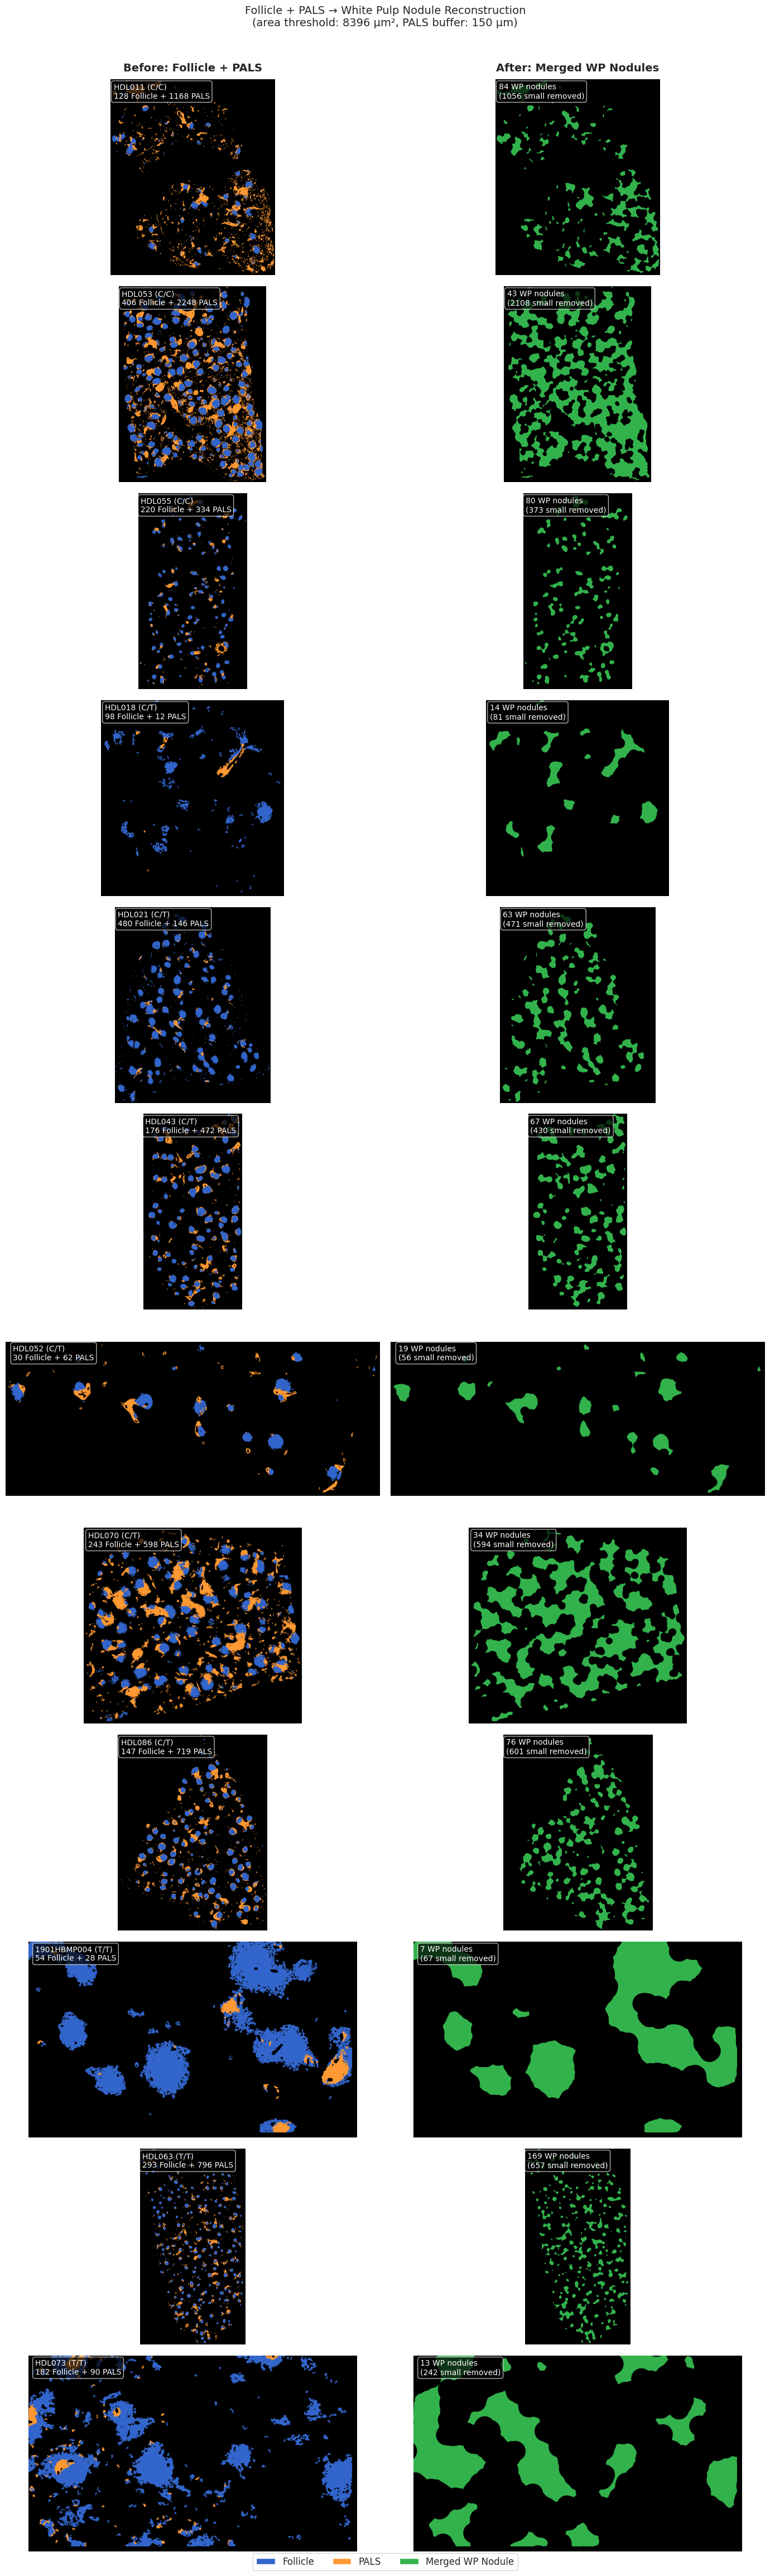

In [16]:
from matplotlib.patches import Patch

RENDER_SCALE = 0.25  # 4× downsample for mask rasterization

# Build list of (geojson_path, sample, genotype) for all analysis images
all_images = []
for gj in geojson_files:
    sample = extract_sample_id(gj.stem)
    if sample in EXCLUDE_SAMPLES:
        continue
    geno = GENOTYPE_MAP.get(sample)
    if geno is None:
        continue
    all_images.append((gj, sample, geno))

# Sort by genotype order then sample name
geno_rank = {g: i for i, g in enumerate(GENO_ORDER)}
all_images.sort(key=lambda x: (geno_rank.get(x[2], 99), x[1]))

print(f"Rendering masks for {len(all_images)} images...\n")

n_rows = len(all_images)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3.8 * n_rows))

for row, (gj_path, sample, geno) in enumerate(all_images):
    annotations = load_annotations_geojson(gj_path)
    fol_polys = annotations.get('Follicle', [])
    pals_polys = annotations.get('PALS', [])

    # Per-image pixel size for threshold conversion
    px_size = get_pixel_size(sample)
    area_thresh_px2 = AREA_THRESHOLD / (px_size ** 2)
    buffer_px = PALS_BUFFER / px_size

    print(f"{sample} ({geno}, {px_size:.3f} µm/px): "
          f"{len(fol_polys)} Follicle, {len(pals_polys)} PALS", end='')

    # Bounding box of all annotations with padding
    all_polys = fol_polys + pals_polys
    bounds = unary_union(all_polys).bounds
    pad = 200
    ox, oy = max(0, bounds[0] - pad), max(0, bounds[1] - pad)
    ex, ey = bounds[2] + pad, bounds[3] + pad

    w = int(np.ceil((ex - ox) * RENDER_SCALE))
    h = int(np.ceil((ey - oy) * RENDER_SCALE))

    def xform(polys, _ox=ox, _oy=oy):
        """Shift to crop origin and scale down for rasterization."""
        return [sscale(stranslate(p, -_ox, -_oy),
                       xfact=RENDER_SCALE, yfact=RENDER_SCALE, origin=(0, 0))
                for p in polys if not p.is_empty]

    # --- BEFORE: original Follicle + PALS ---
    mask_fol = polygons_to_mask(xform(fol_polys), (h, w))
    mask_pals = polygons_to_mask(xform(pals_polys), (h, w))

    rgb_before = np.zeros((h, w, 3))
    rgb_before[mask_pals] = [1.0, 0.6, 0.2]   # orange = PALS
    rgb_before[mask_fol] = [0.2, 0.4, 0.8]    # blue = Follicle (on top)

    axes[row, 0].imshow(rgb_before)

    # --- AFTER: area-filtered + spatially merged WP nodules ---
    fol_large = [p for p in fol_polys if p.area >= area_thresh_px2]
    pals_large = [p for p in pals_polys if p.area >= area_thresh_px2]
    merged = merge_nearby_polygons(fol_large + pals_large, buffer_px)

    mask_merged = polygons_to_mask(xform(merged), (h, w))

    rgb_after = np.zeros((h, w, 3))
    rgb_after[mask_merged] = [0.2, 0.7, 0.3]  # green = merged WP

    axes[row, 1].imshow(rgb_after)

    # Text overlays
    label_kw = dict(fontsize=10, va='top', ha='left', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.7))
    axes[row, 0].text(0.02, 0.98,
                      f'{sample} ({geno})\n{len(fol_polys)} Follicle + {len(pals_polys)} PALS',
                      transform=axes[row, 0].transAxes, **label_kw)
    n_removed = len(fol_polys) - len(fol_large) + len(pals_polys) - len(pals_large)
    axes[row, 1].text(0.02, 0.98,
                      f'{len(merged)} WP nodules\n({n_removed} small removed)',
                      transform=axes[row, 1].transAxes, **label_kw)

    for ax in axes[row]:
        ax.set_axis_off()

    print(f" → {len(merged)} WP nodules")

# Column headers
axes[0, 0].set_title('Before: Follicle + PALS', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_title('After: Merged WP Nodules', fontsize=14, fontweight='bold', pad=10)

# Shared legend
legend_elements = [
    Patch(facecolor=(0.2, 0.4, 0.8), label='Follicle'),
    Patch(facecolor=(1.0, 0.6, 0.2), label='PALS'),
    Patch(facecolor=(0.2, 0.7, 0.3), label='Merged WP Nodule'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12,
           frameon=True, bbox_to_anchor=(0.5, -0.005))

fig.suptitle(f'Follicle + PALS → White Pulp Nodule Reconstruction\n'
             f'(area threshold: {AREA_THRESHOLD:.0f} µm², PALS buffer: {PALS_BUFFER} µm)',
             fontsize=14, y=1.005)
fig.tight_layout()
save_figure(fig, 'H6_WP_nodule_multipanel')
plt.show()

---
## 7. Summary

| Strategy | What it does | Key parameter |
|---|---|---|
| **S3: Area threshold** | Removes spurious small annotations | GMM-derived threshold (µm²) |
| **S2: Spatial clustering** | Merges PALS-fragmented follicles | `PALS_BUFFER` (µm) |
| **S1: White Pulp composite** | Treats Follicle+PALS as one unit | Same buffer; includes PALS vessels |

Check the sensitivity plot and genotype comparison grid above to assess which approach (or combination) best captures the biology.